In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
file_path = "v2healthy_2025-04-09.csv"
df = pd.read_csv(file_path)
df.head()

,Timestamp,Time (s),ENS160_R0 (Ohm),ENS160_R1 (Ohm),ENS160_R2 (Ohm),ENS160_R3 (Ohm),SGP41_VOC_R (Ohm),SGP41_NOx_R (Ohm),TGS2602 (Ohm),SCD40 CO2 (ppm),SCD40 Temp (Celsius),SCD40 H (%RH),MQ3 (Ohm)
0,2025-04-09 15:28:48.44,0.0,26764,1,16147,10584,27335,0,14769.98,-,-,-,15447.76
1,2025-04-09 15:28:49.44,1.0,26583,1,16092,10332,27441,0,16710.18,-,-,-,17280.00
2,2025-04-09 15:28:50.44,2.0,26556,1,16223,10343,27518,0,17723.58,-,-,-,18575.42
3,2025-04-09 15:28:51.44,3.0,26782,1,16295,10573,27584,0,18416.67,441,25.41,21.04,19312.32
4,2025-04-09 15:28:52.45,4.0,26700,1,16367,10648,27625,0,19145.30,-,-,-,19825.07


In [3]:
# CLEAN

# drop timestamp
df = df.drop('Timestamp',axis=1)

# rename columns
df = df.rename(columns={"Time (s)": "Time_s",
                        "ENS160_R0 (Ohm)": "ENS160_R0",
                        "ENS160_R1 (Ohm)": "ENS160_R1",
                        "ENS160_R2 (Ohm)": "ENS160_R2",
                        "ENS160_R3 (Ohm)": "ENS160_R3",
                        "SGP41_VOC_R (Ohm)": "SGP41_VOC_R",
                        "SGP41_NOx_R (Ohm)": "SGP41_NOx_R",
                        "TGS2602 (Ohm)": "TGS2602_R",
                        "SCD40 CO2 (ppm)": "SCD40_CO2",
                        "SCD40 Temp (Celsius)": "SCD40_T",
                        "SCD40 H (%RH)": "SCD40_H",
                        "MQ3 (Ohm)": "MQ3_R"
                       })

# change "-" to null
df = df.replace('-', np.nan)

df

,Time_s,ENS160_R0,ENS160_R1,ENS160_R2,ENS160_R3,SGP41_VOC_R,SGP41_NOx_R,TGS2602_R,SCD40_CO2,SCD40_T,SCD40_H,MQ3_R
0,0.00,26764,1,16147,10584,27335,0,14769.98,NaN,NaN,NaN,15447.76
1,1.00,26583,1,16092,10332,27441,0,16710.18,NaN,NaN,NaN,17280.00
2,2.00,26556,1,16223,10343,27518,0,17723.58,NaN,NaN,NaN,18575.42
3,3.00,26782,1,16295,10573,27584,0,18416.67,441,25.41,21.04,19312.32
4,4.00,26700,1,16367,10648,27625,0,19145.30,NaN,NaN,NaN,19825.07
...,...,...,...,...,...,...,...,...,...,...,...,...
7336,7336.26,55614,1,24910,22998,28250,15698,20906.35,NaN,NaN,NaN,22683.71
7337,7337.26,NaN,NaN,NaN,NaN,28251,15697,22169.81,NaN,NaN,NaN,22788.46
7338,7338.26,55502,1,24492,21860,28243,15698,21284.41,438,24.53,20.31,22068.97
7339,7339.26,55314,1,24081,21756,28244,15702,21574.08,NaN,NaN,NaN,22373.42


In [4]:
# calculate sensor response
res_cols = ["ENS160_R0", "ENS160_R1", "ENS160_R2", "ENS160_R3", "SGP41_VOC_R", "SGP41_NOx_R", "TGS2602_R", "SCD40_CO2", "SCD40_T", "SCD40_H", "MQ3_R"] #define all resistance columns

# create sensor response df
df_s = df[['Time_s']].copy()

df = df.astype(float)
for col in res_cols:
    r = df[col]
    r_max = r.max()
    s_col = col.replace("_R", "_S")

    df_s[s_col] = np.where(r != 0, r_max / r - 1, np.nan)

In [5]:
df_s

,Time_s,ENS160_S0,ENS160_S1,ENS160_S2,ENS160_S3,SGP41_VOC_S,SGP41_NOx_S,TGS2602_S,SCD40_CO2,SCD40_T,SCD40_H,MQ3_S
0,0.00,1.892318,0.0,2.357899,1.247732,0.096506,NaN,0.564444,NaN,NaN,NaN,0.538241
1,1.00,1.912011,0.0,2.369376,1.302555,0.092271,NaN,0.382798,NaN,NaN,NaN,0.375138
2,2.00,1.914972,0.0,2.342169,1.300106,0.089214,NaN,0.303732,NaN,NaN,NaN,0.279238
3,3.00,1.890374,0.0,2.327401,1.250071,0.086608,NaN,0.254668,0.936508,0.000000,0.196768,0.230426
4,4.00,1.899251,0.0,2.312763,1.234222,0.084995,NaN,0.206918,NaN,NaN,NaN,0.198603
...,...,...,...,...,...,...,...,...,...,...,...,...
7336,7336.26,0.391916,0.0,1.176636,0.034438,0.060991,0.097592,0.105253,NaN,NaN,NaN,0.047553
7337,7337.26,NaN,NaN,NaN,NaN,0.060954,0.097662,0.042264,NaN,NaN,NaN,0.042737
7338,7338.26,0.394725,0.0,1.213784,0.088289,0.061254,0.097592,0.085621,0.949772,0.035874,0.239783,0.076733
7339,7339.26,0.399465,0.0,1.251568,0.093491,0.061217,0.097312,0.071045,NaN,NaN,NaN,0.062081


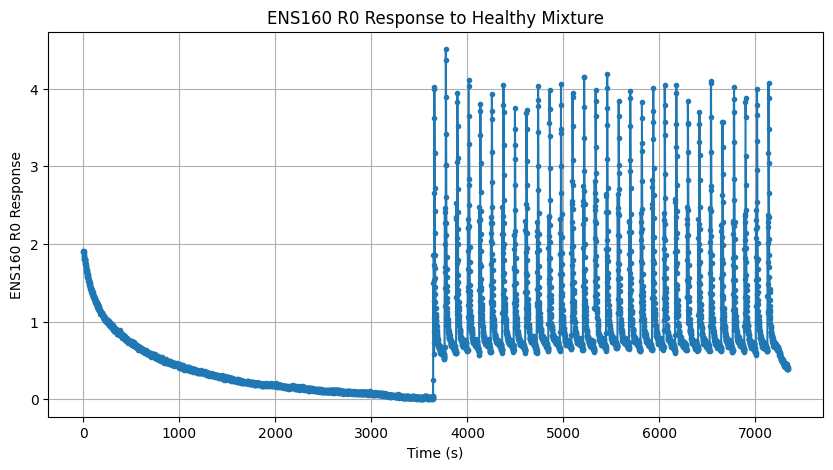

In [6]:
# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df_s["Time_s"],
    df_s["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
plt.title('ENS160 R0 Response to Healthy Mixture')
plt.xlabel('Time (s)')
plt.ylabel('ENS160 R0 Response')
plt.grid()
plt.show()

In [7]:
# drop 3613
df_s = df_s.drop(index=range(0, 3613)).reset_index(drop=True).copy()
df_s["Time_s"] = df_s["Time_s"] - df_s["Time_s"].iloc[0]

In [8]:
df_s

,Time_s,ENS160_S0,ENS160_S1,ENS160_S2,ENS160_S3,SGP41_VOC_S,SGP41_NOx_S,TGS2602_S,SCD40_CO2,SCD40_T,SCD40_H,MQ3_S
0,0.00,0.023630,0.0,0.049941,0.267381,0.002509,0.103144,0.051803,NaN,NaN,NaN,0.066951
1,1.00,0.013631,0.0,0.047102,0.247378,0.002676,0.102438,0.061396,NaN,NaN,NaN,0.062081
2,2.00,0.012266,0.0,0.045689,0.296882,0.002408,0.102367,0.061396,NaN,NaN,NaN,0.033147
3,3.00,0.013631,0.0,0.032664,0.258797,0.002777,0.102156,0.061396,0.836559,0.022124,0.173346,0.057225
4,4.00,0.027448,0.0,0.053143,0.306999,0.002341,0.102156,0.066214,NaN,NaN,NaN,0.066951
...,...,...,...,...,...,...,...,...,...,...,...,...
3723,3723.26,0.391916,0.0,1.176636,0.034438,0.060991,0.097592,0.105253,NaN,NaN,NaN,0.047553
3724,3724.26,NaN,NaN,NaN,NaN,0.060954,0.097662,0.042264,NaN,NaN,NaN,0.042737
3725,3725.26,0.394725,0.0,1.213784,0.088289,0.061254,0.097592,0.085621,0.949772,0.035874,0.239783,0.076733
3726,3726.26,0.399465,0.0,1.251568,0.093491,0.061217,0.097312,0.071045,NaN,NaN,NaN,0.062081


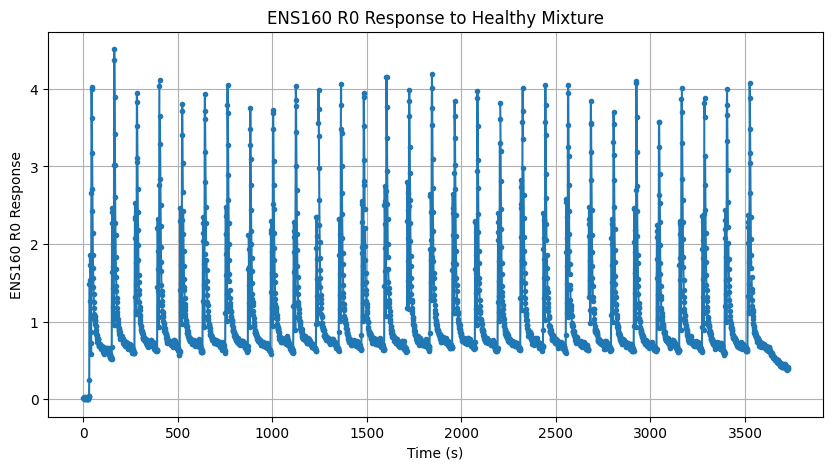

In [9]:
# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df_s["Time_s"],
    df_s["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
plt.title('ENS160 R0 Response to Healthy Mixture')
plt.xlabel('Time (s)')
plt.ylabel('ENS160 R0 Response')
plt.grid()
plt.show()

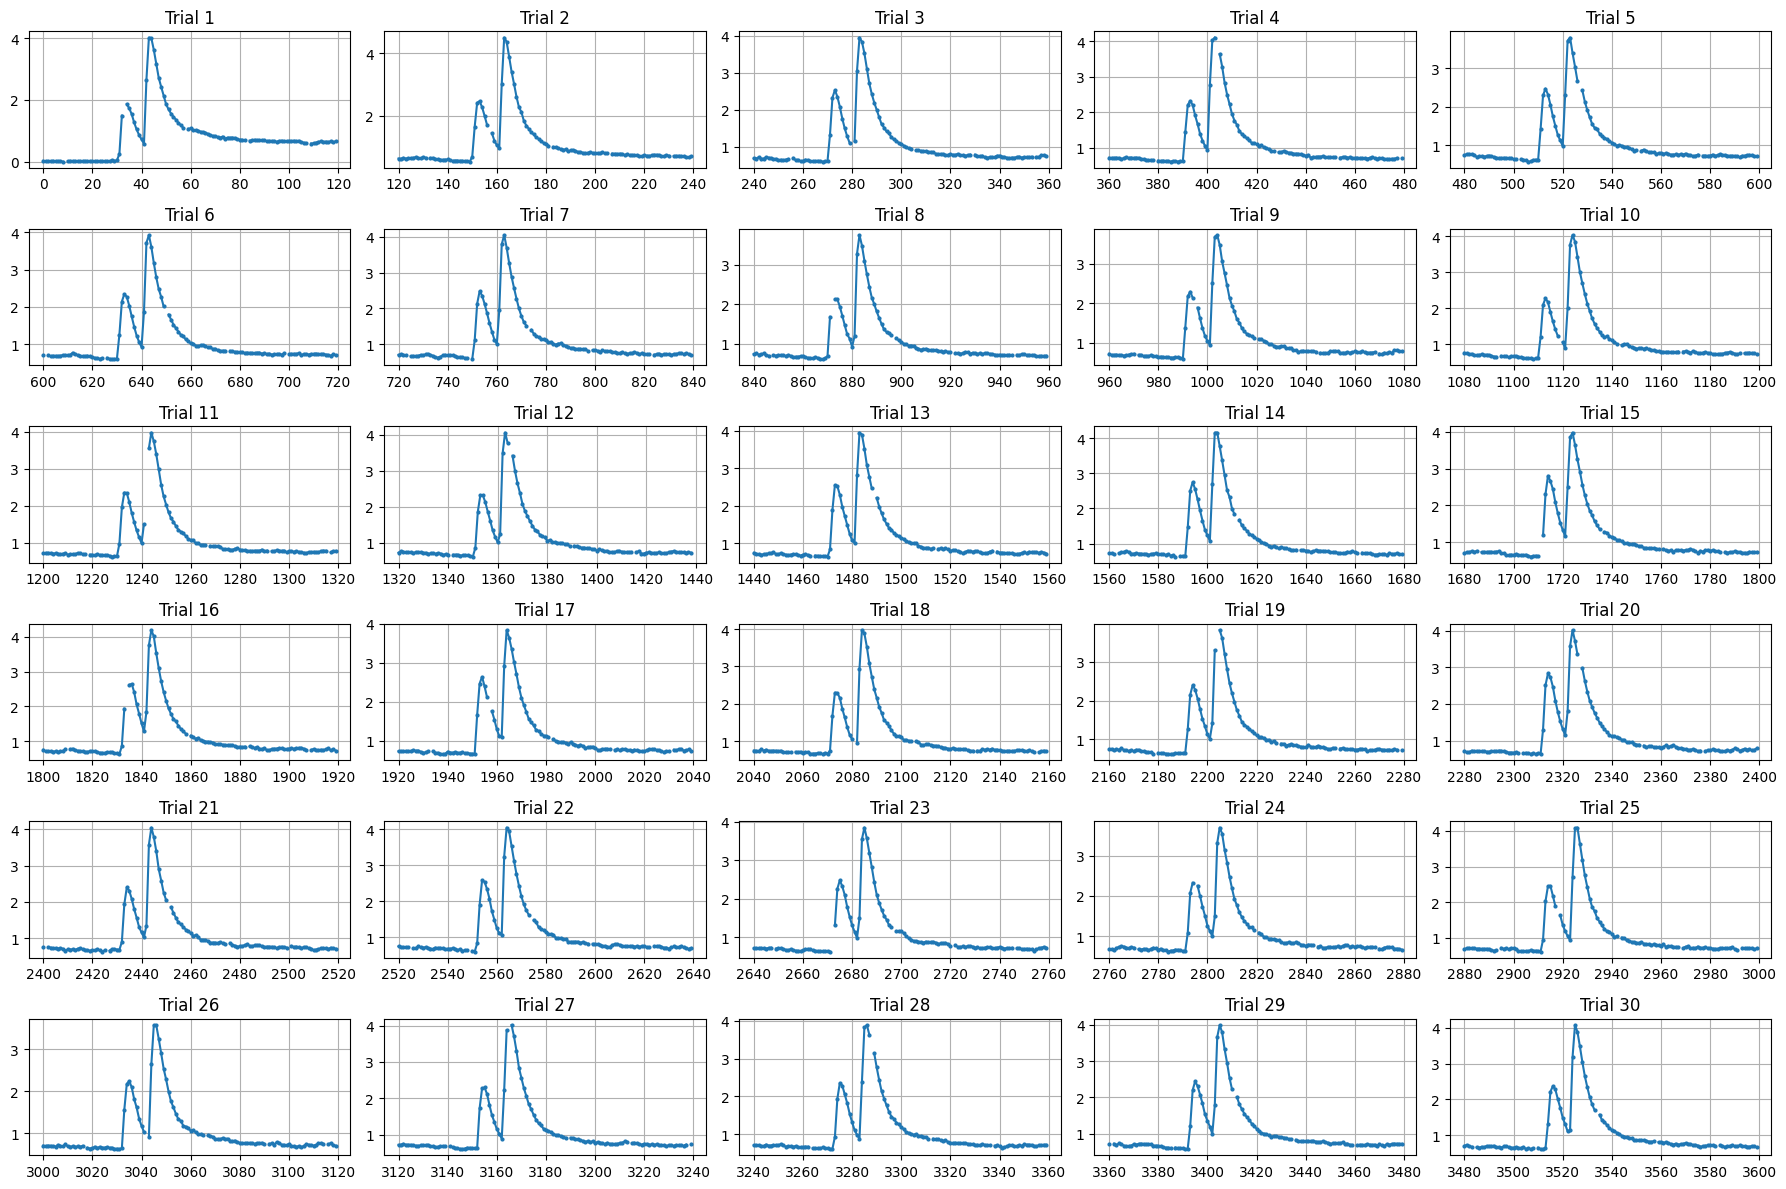

In [10]:
# parameters
segment_length = 120 # seconds
n_plots = 30

time = df_s["Time_s"].values
signal = df_s["ENS160_S0"].values

fig, axes = plt.subplots(6, 5, figsize=(18, 12))  # 6x5 = 30 plots
axes = axes.flatten()

start_time = time.min()

for i in range(n_plots):
    t_start = start_time + i * segment_length
    t_end = t_start + segment_length

    # mask for this segment
    mask = (time >= t_start) & (time < t_end)

    axes[i].plot(time[mask], signal[mask], marker="o", linestyle="-", markersize=2)
    axes[i].set_title(f"Trial {i+1}")
    axes[i].grid()

# clean layout
plt.tight_layout()
plt.show()

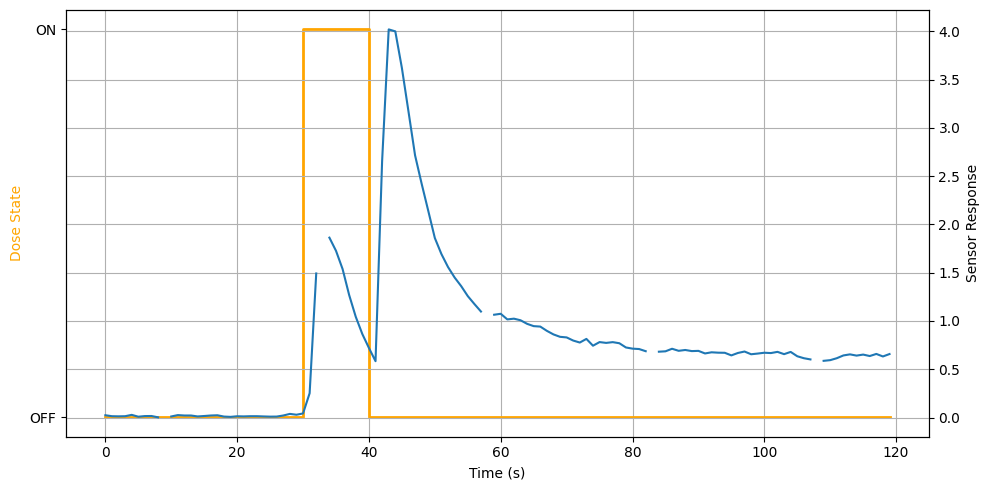

In [22]:
t_start = start_time
t_end = t_start + segment_length

# mask for this segment
mask = (time >= t_start) & (time < t_end)

t_seg = time[mask]
y_seg = signal[mask]

# define dosing profile
dosing = [0]*30 + [1]*10 + [0]*80

# match dosing length to selected segment
if len(dosing) < len(t_seg):
    dosing = dosing + [0] * (len(t_seg) - len(dosing))
else:
    dosing = dosing[:len(t_seg)]

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.step(t_seg, dosing, where="post", color="orange", linewidth=2)
ax1.set_ylabel("Dose State", color="orange")
ax1.set_xlabel("Time (s)")
ax1.set_yticks([0, 1])
ax1.set_yticklabels(["OFF", "ON"])

ax2 = ax1.twinx()
ax2.plot(t_seg, y_seg)
ax2.set_ylabel("Sensor Response")

ax1.xaxis.grid(True)
ax2.yaxis.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# drop time_s
df_s = df_s.drop(['Time_s','ENS160_S1','SGP41_NOx_S'],axis=1)
df_s

,ENS160_S0,ENS160_S2,ENS160_S3,SGP41_VOC_S,TGS2602_S,SCD40_CO2,SCD40_T,SCD40_H,MQ3_S
0,0.023630,0.049941,0.267381,0.002509,0.051803,NaN,NaN,NaN,0.066951
1,0.013631,0.047102,0.247378,0.002676,0.061396,NaN,NaN,NaN,0.062081
2,0.012266,0.045689,0.296882,0.002408,0.061396,NaN,NaN,NaN,0.033147
3,0.013631,0.032664,0.258797,0.002777,0.061396,0.836559,0.022124,0.173346,0.057225
4,0.027448,0.053143,0.306999,0.002341,0.066214,NaN,NaN,NaN,0.066951
...,...,...,...,...,...,...,...,...,...
3723,0.391916,1.176636,0.034438,0.060991,0.105253,NaN,NaN,NaN,0.047553
3724,NaN,NaN,NaN,0.060954,0.042264,NaN,NaN,NaN,0.042737
3725,0.394725,1.213784,0.088289,0.061254,0.085621,0.949772,0.035874,0.239783,0.076733
3726,0.399465,1.251568,0.093491,0.061217,0.071045,NaN,NaN,NaN,0.062081


In [16]:
# parameters
output_dir = "snippets"
os.makedirs(output_dir, exist_ok=True)

for i in range(n_plots):
    # define segment bounds
    beg = i * segment_length
    end = beg + segment_length

    # extract segment
    segment_df = df_s.iloc[beg:end].copy()

    # skip empty segments
    if segment_df.empty:
        continue

    # flatten all values in this segment into one 1D row
    flat_values = segment_df.to_numpy().flatten()

    # save as one-row csv
    filename = f"trial{i+1}_healthy.csv"
    pd.DataFrame([flat_values]).to_csv(
        os.path.join(output_dir, filename),
        index=False,
        header=False
    )

In [23]:
# REPEAT FOR UNHEALTHY
file_path = "v2unhealthy_2025-04-09.csv"
df = pd.read_csv(file_path)
df.head()

,Timestamp,Time (s),ENS160_R0 (Ohm),ENS160_R1 (Ohm),ENS160_R2 (Ohm),ENS160_R3 (Ohm),SGP41_VOC_R (Ohm),SGP41_NOx_R (Ohm),TGS2602 (Ohm),SCD40 CO2 (ppm),SCD40 Temp (Celsius),SCD40 H (%RH),MQ3 (Ohm)
0,2025-04-09 19:27:47.65,0.0,109957,1,66993,32491,27145,0,17798.91,-,-,-,18416.67
1,2025-04-09 19:27:48.65,1.0,109585,1,67814,32690,27510,0,19312.32,-,-,-,19912.28
2,2025-04-09 19:27:49.65,2.0,111229,1,67746,32044,27826,0,20356.08,-,-,-,21380.37
3,2025-04-09 19:27:50.65,3.0,110628,1,67837,31979,28085,0,21094.23,465,28.61,16.00,21869.16
4,2025-04-09 19:27:51.65,4.0,110628,1,67814,33124,28305,0,20537.32,-,-,-,21869.16


In [25]:
# CLEAN

# drop timestamp
df = df.drop('Timestamp',axis=1)

# rename columns
df = df.rename(columns={"Time (s)": "Time_s",
                        "ENS160_R0 (Ohm)": "ENS160_R0",
                        "ENS160_R1 (Ohm)": "ENS160_R1",
                        "ENS160_R2 (Ohm)": "ENS160_R2",
                        "ENS160_R3 (Ohm)": "ENS160_R3",
                        "SGP41_VOC_R (Ohm)": "SGP41_VOC_R",
                        "SGP41_NOx_R (Ohm)": "SGP41_NOx_R",
                        "TGS2602 (Ohm)": "TGS2602_R",
                        "SCD40 CO2 (ppm)": "SCD40_CO2",
                        "SCD40 Temp (Celsius)": "SCD40_T",
                        "SCD40 H (%RH)": "SCD40_H",
                        "MQ3 (Ohm)": "MQ3_R"
                       })

# change "-" to null
df = df.replace('-', np.nan)

df

,Time_s,ENS160_R0,ENS160_R1,ENS160_R2,ENS160_R3,SGP41_VOC_R,SGP41_NOx_R,TGS2602_R,SCD40_CO2,SCD40_T,SCD40_H,MQ3_R
0,0.00,109957,1,66993,32491,27145,0,17798.91,NaN,NaN,NaN,18416.67
1,1.00,109585,1,67814,32690,27510,0,19312.32,NaN,NaN,NaN,19912.28
2,2.00,111229,1,67746,32044,27826,0,20356.08,NaN,NaN,NaN,21380.37
3,3.00,110628,1,67837,31979,28085,0,21094.23,465,28.61,16.00,21869.16
4,4.00,110628,1,67814,33124,28305,0,20537.32,NaN,NaN,NaN,21869.16
...,...,...,...,...,...,...,...,...,...,...,...,...
7445,7445.01,117976,1,62355,37798,28827,15865,22068.97,NaN,NaN,NaN,22476.19
7446,7446.01,117101,1,63076,35927,28821,15861,21968.75,NaN,NaN,NaN,22579.62
7447,7447.01,118697,1,61746,36901,28836,15864,22068.97,NaN,NaN,NaN,23322.47
7448,7448.01,118056,1,61829,38081,28828,15864,22068.97,413,24.29,20.18,22788.46


In [26]:
# calculate sensor response
res_cols = ["ENS160_R0", "ENS160_R1", "ENS160_R2", "ENS160_R3", "SGP41_VOC_R", "SGP41_NOx_R", "TGS2602_R", "SCD40_CO2", "SCD40_T", "SCD40_H", "MQ3_R"] #define all resistance columns

# create sensor response df
df_s = df[['Time_s']].copy()

df = df.astype(float)
for col in res_cols:
    r = df[col]
    r_max = r.max()
    s_col = col.replace("_R", "_S")

    df_s[s_col] = np.where(r != 0, r_max / r - 1, np.nan)

df_s

,Time_s,ENS160_S0,ENS160_S1,ENS160_S2,ENS160_S3,SGP41_VOC_S,SGP41_NOx_S,TGS2602_S,SCD40_CO2,SCD40_T,SCD40_H,MQ3_S
0,0.00,0.168066,0.0,0.196886,0.216491,0.111328,NaN,0.286252,NaN,NaN,NaN,0.266378
1,1.00,0.172031,0.0,0.182396,0.209085,0.096583,NaN,0.185455,NaN,NaN,NaN,0.171261
2,2.00,0.154708,0.0,0.183583,0.233460,0.084130,NaN,0.124671,NaN,NaN,NaN,0.090836
3,3.00,0.160981,0.0,0.181995,0.235967,0.074132,NaN,0.085315,0.212903,0.000000,0.280000,0.066455
4,4.00,0.160981,0.0,0.182396,0.193244,0.065783,NaN,0.114746,NaN,NaN,NaN,0.066455
...,...,...,...,...,...,...,...,...,...,...,...,...
7445,7445.01,0.088671,0.0,0.285911,0.045690,0.046484,0.081563,0.037379,NaN,NaN,NaN,0.037652
7446,7446.01,0.096805,0.0,0.271213,0.100148,0.046702,0.081836,0.042112,NaN,NaN,NaN,0.032899
7447,7447.01,0.082058,0.0,0.298594,0.071109,0.046158,0.081631,0.037379,NaN,NaN,NaN,0.000000
7448,7448.01,0.087933,0.0,0.296851,0.037919,0.046448,0.081631,0.037379,0.365617,0.177851,0.014866,0.023433


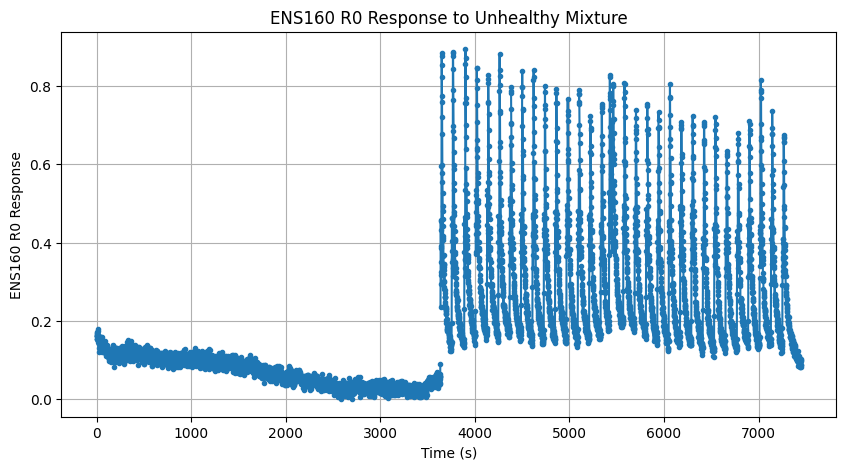

In [27]:
# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df_s["Time_s"],
    df_s["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
plt.title('ENS160 R0 Response to Unhealthy Mixture')
plt.xlabel('Time (s)')
plt.ylabel('ENS160 R0 Response')
plt.grid()
plt.show()

In [28]:
# drop 3605
df_s = df_s.drop(index=range(0, 3605)).reset_index(drop=True).copy()
df_s["Time_s"] = df_s["Time_s"] - df_s["Time_s"].iloc[0]

In [29]:
df_s

,Time_s,ENS160_S0,ENS160_S1,ENS160_S2,ENS160_S3,SGP41_VOC_S,SGP41_NOx_S,TGS2602_S,SCD40_CO2,SCD40_T,SCD40_H,MQ3_S
0,0.00,0.045342,0.0,0.057084,0.263910,0.002692,0.059198,0.046857,NaN,NaN,NaN,0.037652
1,1.00,0.053505,0.0,0.064975,0.297731,0.002459,0.059852,0.046857,0.253333,0.162063,0.011858,0.032899
2,2.00,0.062815,0.0,0.071493,0.302092,0.002792,0.059590,0.051616,NaN,NaN,NaN,0.028159
3,3.00,0.038639,0.0,0.070405,0.295944,0.002659,0.059459,0.042112,NaN,NaN,NaN,0.042419
4,4.00,0.029885,0.0,0.069306,0.296412,0.002759,0.059394,0.051616,NaN,NaN,NaN,0.061620
...,...,...,...,...,...,...,...,...,...,...,...,...
3840,3840.01,0.088671,0.0,0.285911,0.045690,0.046484,0.081563,0.037379,NaN,NaN,NaN,0.037652
3841,3841.01,0.096805,0.0,0.271213,0.100148,0.046702,0.081836,0.042112,NaN,NaN,NaN,0.032899
3842,3842.01,0.082058,0.0,0.298594,0.071109,0.046158,0.081631,0.037379,NaN,NaN,NaN,0.000000
3843,3843.01,0.087933,0.0,0.296851,0.037919,0.046448,0.081631,0.037379,0.365617,0.177851,0.014866,0.023433


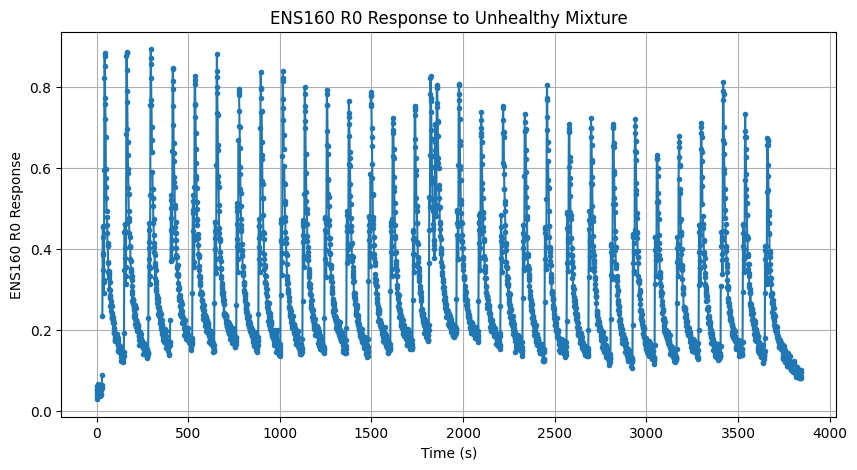

In [30]:
# plot sensitivities (response)
plt.figure(figsize=[10,5])
plt.plot(
    df_s["Time_s"],
    df_s["ENS160_S0"],
    marker="o",
    linestyle="-",
    markersize=3
)
plt.title('ENS160 R0 Response to Unhealthy Mixture')
plt.xlabel('Time (s)')
plt.ylabel('ENS160 R0 Response')
plt.grid()
plt.show()

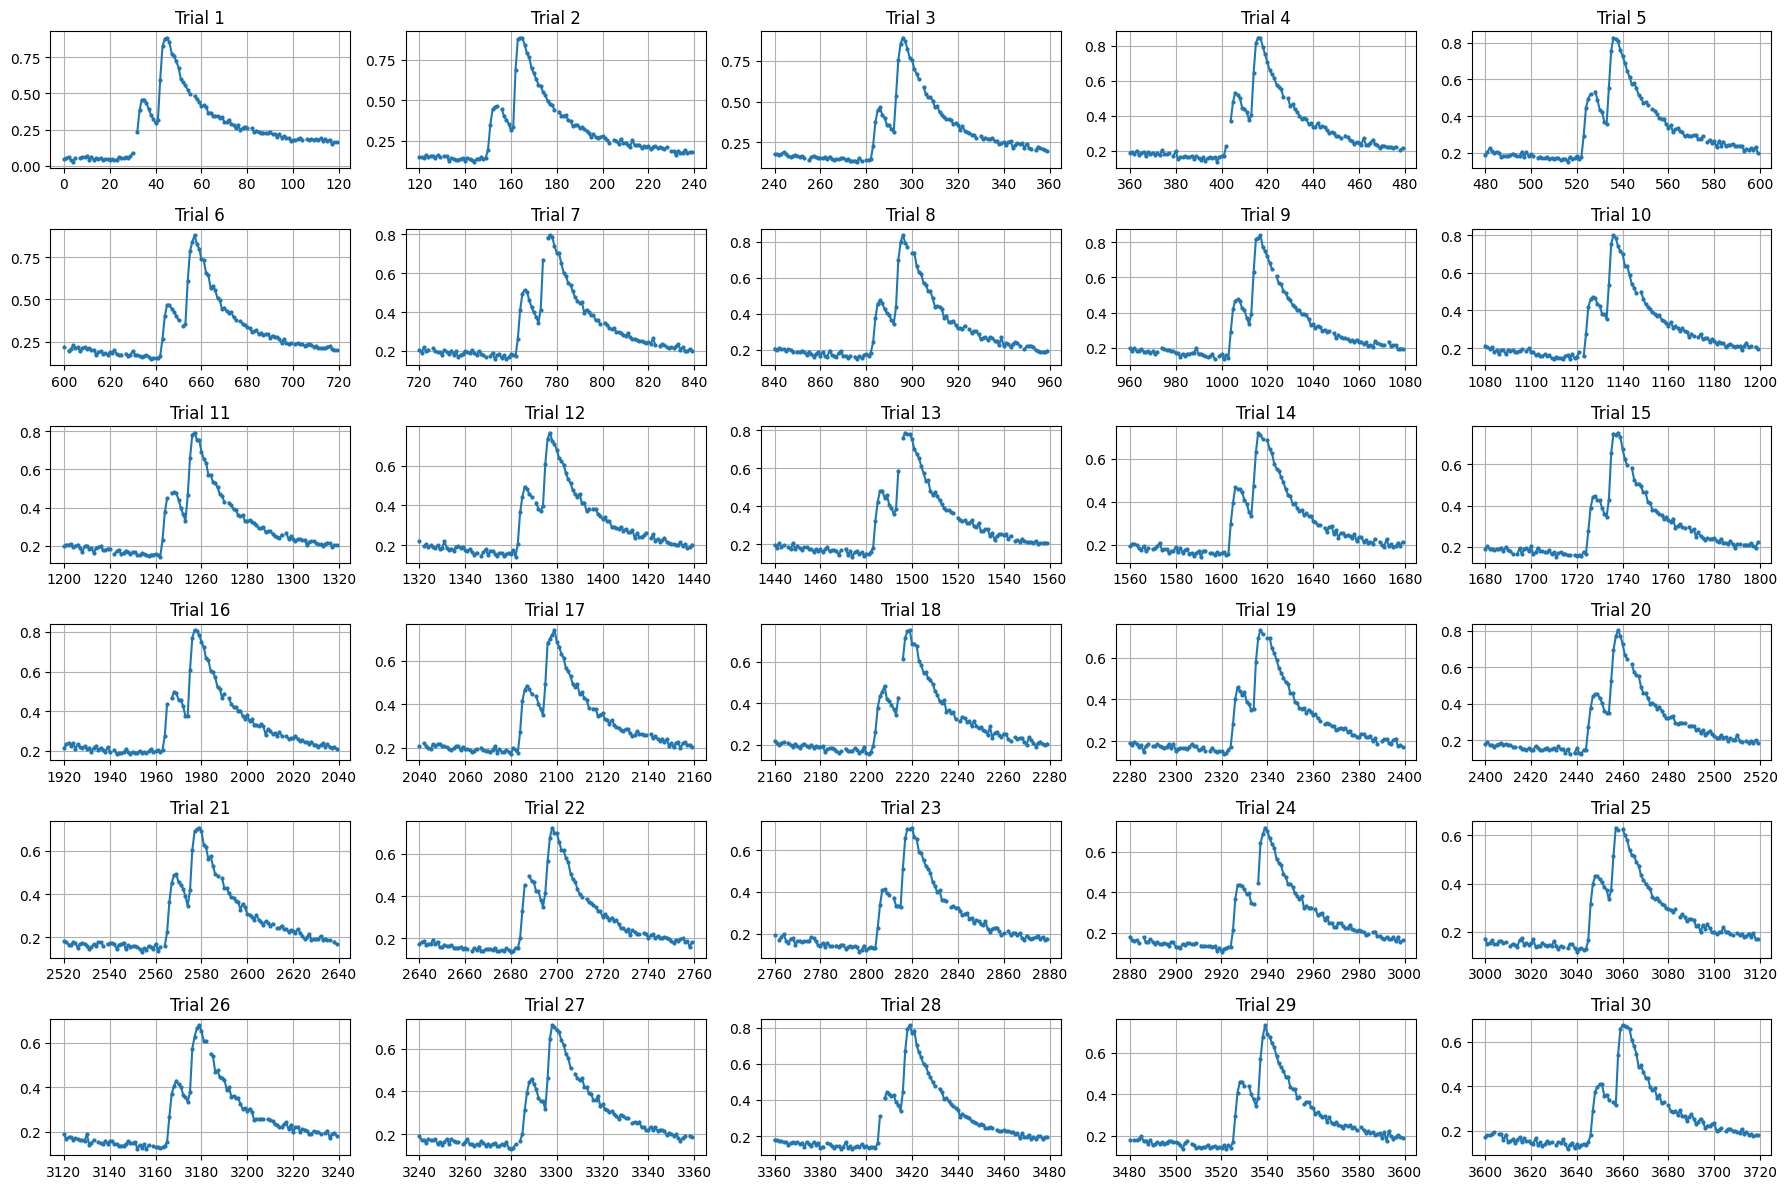

In [31]:
time = df_s["Time_s"].values
signal = df_s["ENS160_S0"].values

fig, axes = plt.subplots(6, 5, figsize=(18, 12))  # 6x5 = 30 plots
axes = axes.flatten()

start_time = time.min()
segment_indices = list(range(31))
segment_indices.pop(15) # remove 16th segment

for plot_idx, seg_idx in enumerate(segment_indices[:30]):
    t_start = start_time + seg_idx * segment_length
    t_end = t_start + segment_length

    mask = (time >= t_start) & (time < t_end)

    axes[plot_idx].plot(time[mask], signal[mask], marker="o", linestyle="-", markersize=2)
    axes[plot_idx].set_title(f"Trial {plot_idx + 1}")
    axes[plot_idx].grid()

plt.tight_layout()
plt.show()

In [33]:
# drop time_s
df_s = df_s.drop(['Time_s','ENS160_S1','SGP41_NOx_S'],axis=1)
df_s

,ENS160_S0,ENS160_S2,ENS160_S3,SGP41_VOC_S,TGS2602_S,SCD40_CO2,SCD40_T,SCD40_H,MQ3_S
0,0.045342,0.057084,0.263910,0.002692,0.046857,NaN,NaN,NaN,0.037652
1,0.053505,0.064975,0.297731,0.002459,0.046857,0.253333,0.162063,0.011858,0.032899
2,0.062815,0.071493,0.302092,0.002792,0.051616,NaN,NaN,NaN,0.028159
3,0.038639,0.070405,0.295944,0.002659,0.042112,NaN,NaN,NaN,0.042419
4,0.029885,0.069306,0.296412,0.002759,0.051616,NaN,NaN,NaN,0.061620
...,...,...,...,...,...,...,...,...,...
3840,0.088671,0.285911,0.045690,0.046484,0.037379,NaN,NaN,NaN,0.037652
3841,0.096805,0.271213,0.100148,0.046702,0.042112,NaN,NaN,NaN,0.032899
3842,0.082058,0.298594,0.071109,0.046158,0.037379,NaN,NaN,NaN,0.000000
3843,0.087933,0.296851,0.037919,0.046448,0.037379,0.365617,0.177851,0.014866,0.023433


In [35]:
segment_indices = list(range(31)) # 0 → 30
segment_indices.pop(15) # remove 16th segment

for trial_idx, seg_idx in enumerate(segment_indices[:30]):
    beg = seg_idx * segment_length
    end = beg + segment_length

    segment_df = df_s.iloc[beg:end].copy()

    if segment_df.empty:
        continue

    # flatten all values in this segment into one 1D row
    flat_values = segment_df.to_numpy().flatten()

    # filename now uses shifted trial index
    filename = f"trial{trial_idx + 1}_unhealthy.csv"
    pd.DataFrame([flat_values]).to_csv(
        os.path.join(output_dir, filename),
        index=False,
        header=False
    )